### Mount Drive & Unzip

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# !unzip "/content/drive/MyDrive/Skin_disease_detection/archive.zip" -d "/content/drive/MyDrive/Skin_disease_detection/"

### Import Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

### Load Metadata

In [33]:
metadata = pd.read_csv('/content/drive/MyDrive/Skin_disease_detection/GroundTruth.csv')
metadata.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
metadata.shape

(10015, 8)

In [35]:
# Define Classes
class_names = ['MEL','NV','BCC','AKIEC','BKL','DF','VASC']

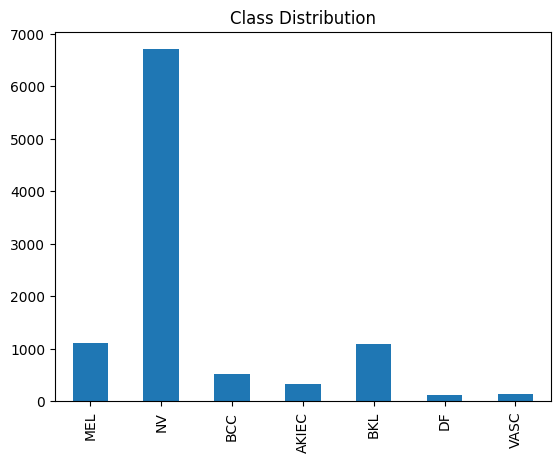

In [36]:
class_counts = metadata[class_names].sum()

class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.show()

### Load & Preprocess Images

In [37]:
image_path = '/content/drive/MyDrive/Skin_disease_detection/images/'

def get_image_path(img_name):
    path = os.path.join(image_path, img_name + ".jpg")
    return path

metadata['path'] = metadata['image'].apply(get_image_path)

### Train Test Split

In [38]:
train_df, test_df = train_test_split(metadata, test_size=0.2, random_state=42)

### Handle Class Imbalance

In [39]:
y_integers = np.argmax(metadata[class_names].values, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(1.2854575792581184), 1: np.float64(0.21338020666879728), 2: np.float64(2.78349082823791), 3: np.float64(4.375273044997815), 4: np.float64(1.301832835044846), 5: np.float64(12.440993788819876), 6: np.float64(10.075452716297788)}


### Batch Processing

In [40]:
IMG_SIZE = 224
BATCH_SIZE = 32

def process_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)
    return img, label

### Data Augmentation

In [41]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

### Create Dataset Pipeline

In [42]:
def create_dataset(df, training=True):
    paths = df['path'].values
    labels = df[class_names].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x), y))

    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

### Build Dataset

In [43]:
train_ds = create_dataset(train_df, True)
test_ds = create_dataset(test_df, False)

### Build MobileNetv2 Model

In [44]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Add Custom Head

In [45]:
x = base_model.output

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(7, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

### Compile Model

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Callbacks

In [47]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/Skin_disease_detection/model.h5',
    save_best_only=True
)

### Train Model (Phase 1)

In [48]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=callbacks + [checkpoint]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.4150 - loss: 2.1503

251/251 ━━━━━━━━━━━━━━━━━━━━ 201s 641ms/step - accuracy: 0.4572 - loss: 2.0138 - val_accuracy: 0.5786 - val_loss: 1.1729 - learning_rate: 0.0010
Epoch 2/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.5155 - loss: 1.3549

251/251 ━━━━━━━━━━━━━━━━━━━━ 154s 547ms/step - accuracy: 0.5232 - loss: 1.3883 - val_accuracy: 0.6016 - val_loss: 1.1552 - learning_rate: 0.0010
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 199s 538ms/step - accuracy: 0.5533 - loss: 1.2142 - val_accuracy: 0.5402 - val_loss: 1.2382 - learning_rate: 0.0010
Epoch 4/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.5718 - loss: 1.0958

251/251 ━━━━━━━━━━━━━━━━━━━━ 204s 544ms/step - accuracy: 0.5745 - loss: 1.1170 - val_accuracy: 0.6061 - val_loss: 1.0474 - learning_rate: 0.0010
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 534ms/step - accuracy: 0.5965 - loss: 1.0273 - val_accuracy: 0.5671 - val_loss: 1.1576 - learning_rate: 0.0010
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 534ms/step - accuracy: 0.5834 - loss: 1.0202 - val_accuracy: 0.5846 - val_loss: 1.1010 - learning_rate: 0.0010
Epoch 7/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.5927 - loss: 0.8673

251/251 ━━━━━━━━━━━━━━━━━━━━ 209s 564ms/step - accuracy: 0.6040 - loss: 0.9229 - val_accuracy: 0.6201 - val_loss: 0.9835 - learning_rate: 0.0010
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 185s 670ms/step - accuracy: 0.5981 - loss: 0.9810 - val_accuracy: 0.5801 - val_loss: 1.0348 - learning_rate: 0.0010
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 171s 562ms/step - accuracy: 0.6041 - loss: 0.9629 - val_accuracy: 0.6011 - val_loss: 1.0409 - learning_rate: 0.0010
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 534ms/step - accuracy: 0.6077 - loss: 0.9441 - val_accuracy: 0.5886 - val_loss: 1.0659 - learning_rate: 0.0010


### Fine Tuning

In [49]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

### Recompile

In [50]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Again

In [51]:
history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=callbacks + [checkpoint]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 187s 602ms/step - accuracy: 0.5077 - loss: 1.3428 - val_accuracy: 0.7189 - val_loss: 1.0493 - learning_rate: 1.0000e-05
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 155s 552ms/step - accuracy: 0.5107 - loss: 1.1276 - val_accuracy: 0.7134 - val_loss: 1.0134 - learning_rate: 1.0000e-05
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.5244 - loss: 1.0577

251/251 ━━━━━━━━━━━━━━━━━━━━ 161s 581ms/step - accuracy: 0.5286 - loss: 1.0811 - val_accuracy: 0.7089 - val_loss: 0.9042 - learning_rate: 1.0000e-05
Epoch 4/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.5342 - loss: 1.0055

251/251 ━━━━━━━━━━━━━━━━━━━━ 200s 572ms/step - accuracy: 0.5439 - loss: 1.0452 - val_accuracy: 0.7169 - val_loss: 0.8419 - learning_rate: 1.0000e-05
Epoch 5/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.5518 - loss: 1.0117

251/251 ━━━━━━━━━━━━━━━━━━━━ 202s 570ms/step - accuracy: 0.5498 - loss: 0.9864 - val_accuracy: 0.7089 - val_loss: 0.8174 - learning_rate: 1.0000e-05
Epoch 6/10
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.5663 - loss: 0.9037

251/251 ━━━━━━━━━━━━━━━━━━━━ 203s 570ms/step - accuracy: 0.5658 - loss: 0.9305 - val_accuracy: 0.7014 - val_loss: 0.8125 - learning_rate: 1.0000e-05
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 161s 572ms/step - accuracy: 0.5779 - loss: 0.8938 - val_accuracy: 0.6965 - val_loss: 0.8142 - learning_rate: 1.0000e-05
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 198s 562ms/step - accuracy: 0.5845 - loss: 0.8890 - val_accuracy: 0.6835 - val_loss: 0.8350 - learning_rate: 1.0000e-05
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 155s 557ms/step - accuracy: 0.5916 - loss: 0.8710 - val_accuracy: 0.6810 - val_loss: 0.8415 - learning_rate: 1.0000e-05
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 162s 581ms/step - accuracy: 0.5989 - loss: 0.8529 - val_accuracy: 0.6710 - val_loss: 0.8557 - learning_rate: 1.0000e-06


### Evaluation

In [52]:
model.evaluate(test_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.7014 - loss: 0.8125


[0.8125169277191162, 0.7014478445053101]

### Predictions

In [53]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22

### Confusion Matrix

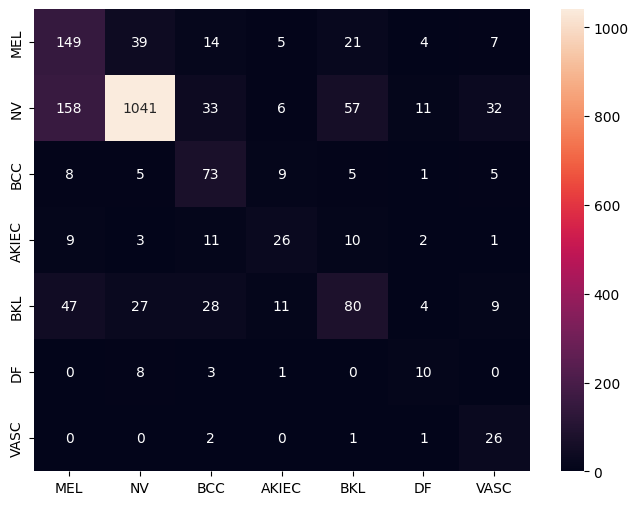

In [54]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.show()

In [55]:
# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         MEL       0.40      0.62      0.49       239
          NV       0.93      0.78      0.85      1338
         BCC       0.45      0.69      0.54       106
       AKIEC       0.45      0.42      0.43        62
         BKL       0.46      0.39      0.42       206
          DF       0.30      0.45      0.36        22
        VASC       0.33      0.87      0.47        30

    accuracy                           0.70      2003
   macro avg       0.47      0.60      0.51      2003
weighted avg       0.76      0.70      0.72      2003



In [56]:
model.save( '/content/drive/MyDrive/Skin_disease_detection/final_skin_model.h5')